This notebook demonstrates the training and evaluation of a simple neural network model for digit classification using the MNIST dataset. The model utilizes PyTorch, a popular open-source machine learning framework, to define, train, and evaluate the neural network. This technology is widely used in various applications involving image recognition and deep learning.

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [14]:
transforms=transforms.ToTensor()
train_data=MNIST(
    root='data',
    train=True,
    download=True,
    transform=transforms
)
test_data=MNIST(
    root='data',
    train=False,
    download=True,
    transform=transforms
)
train_loader=DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)
test_loader=DataLoader(
    test_data,
    batch_size=64,
    shuffle=True
)

In [15]:
class DigitModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.net=nn.Sequential(
        nn.Linear(28*28,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10)
    )
  def forward(self,x):
    return self.net(x)

In [16]:
model=DigitModel()
loss_fn=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)


In [17]:
epochs=5
for epoch in range(epochs):
  model.train()
  total_loss=0
  for image,lables in train_loader:
    images=image.view(image.shape[0],-1)
    label=lables
    optimizer.zero_grad()
    output=model(images)
    loss=loss_fn(output,lables)
    loss.backward()
    optimizer.step()
    total_loss+=loss.item()
  print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader)}")

Epoch 1/5, Loss: 0.3409940002124701
Epoch 2/5, Loss: 0.13861260529774339
Epoch 3/5, Loss: 0.09541915999358094
Epoch 4/5, Loss: 0.07130343197454721
Epoch 5/5, Loss: 0.05569207118595761


In [18]:
model.eval()
correct=0
total=0
with torch.no_grad():
  for images,lables in test_loader:
    images=images.view(images.shape[0],-1)
    output=model(images)
    preditions=output.argmax(dim=1)
    correct+=preditions.eq(lables).sum().item()
    total+=lables.shape[0]
print(f"Accuracy: {correct/total}")

Accuracy: 0.974


In [19]:
torch.save(model.state_dict(),'model.pth')

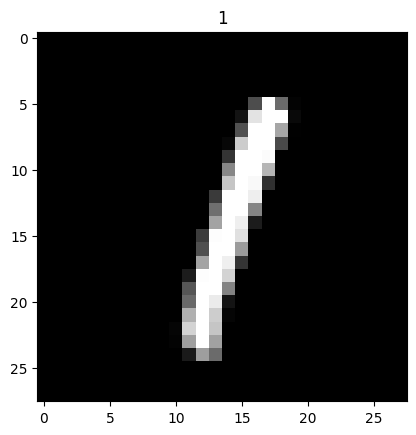

Predicted Label: 1


In [22]:
from numpy import squeeze
index=5
image,true_label=test_data[index]
plt.imshow(image.squeeze(),cmap='gray')
plt.title(true_label)
plt.show()
image_flat=image.view(1,-1)
with torch.no_grad():
  output=model(image_flat)
  predi_label=output.argmax(dim=1)
  print(f"Predicted Label: {predi_label.item()}")